# Ablated Trajectory Analysis

This notebook analyzes pre-extracted ablated teacher trajectories using the same pipeline as prospective_memory_analysis.ipynb.

**Key differences from original:**
- Loads pre-extracted trajectory data (no live model inference)
- Can analyze any timepoint in the diffusion trajectory
- Analyzes effects of neuron ablation on neural representations

**Pipeline:**
1. Load pre-extracted trajectories
2. Extract neural states at specific timepoint
3. Organize by trial metadata
4. Bin by cued color
5. PCA and visualization

## 1. Setup and Load Pre-Extracted Data

In [34]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from pathlib import Path
import torch
import json

# Paths
REPO_ROOT = Path('/scratch3/shaiq_home/repos/behaviour_ddpm')
sys.path.insert(0, str(REPO_ROOT))

# Configuration
TRAJECTORY_DATA_PATH = REPO_ROOT / "results_link_sampler/index_cued_first_diffusion_0.3_swap_7/ablation_trajectories_neuron_0/ablated_trajectories.pt"
# Or use: REPO_ROOT / "results_link_sampler/index_cued_first_diffusion_0.3_swap_7/ablation_trajectories_neuron_0/ablated_trajectories.pt"

TIMEPOINT = 20  # Which diffusion timestep to analyze (0-39, or can use prep states)
ANGLE_STEP = 30  # Angle step in degrees
N_BINS = 12  # Number of angular bins (360/30 = 12)
USE_PREP_STATES = False  # If True, use prep epoch states instead of diffusion timepoint

print(f"Loading trajectory data from:")
print(f"  {TRAJECTORY_DATA_PATH}")

Loading trajectory data from:
  /scratch3/shaiq_home/repos/behaviour_ddpm/results_link_sampler/index_cued_first_diffusion_0.3_swap_7/ablation_trajectories_neuron_0/ablated_trajectories.pt


In [35]:
# Load the pre-extracted trajectory data
data = torch.load(TRAJECTORY_DATA_PATH, map_location='cpu', weights_only=False)

print("\n=== Data Contents ===")
for key in data.keys():
    val = data[key]
    if isinstance(val, torch.Tensor):
        print(f"  {key}: {val.shape}")
        # Check for NaN in tensors
        if val.dtype in [torch.float32, torch.float64, torch.float16]:
            nan_count = torch.isnan(val).sum().item()
            total = val.numel()
            if nan_count > 0:
                print(f"    ⚠ Contains {nan_count}/{total} NaN values ({100*nan_count/total:.1f}%)")
    elif isinstance(val, dict):
        print(f"  {key}: dict")
    elif isinstance(val, list):
        print(f"  {key}: list of length {len(val)}")

# Load metadata
if 'metadata' in data:
    metadata = data['metadata']
    print(f"\n=== Metadata ===")
    print(f"  Ablated neuron: {metadata.get('ablate_neuron', 'N/A')}")
    print(f"  Number of trials: {metadata.get('num_trials', 'N/A')}")
    print(f"  Samples per trial: {metadata.get('num_samples', 'N/A')}")
    print(f"  Source model: {Path(metadata.get('source_run_path', '')).name}")

# Detailed inspection of trajectory data
print(f"\n=== Detailed Trajectory Inspection ===")
if 'embedded_sample_trajectory' in data and data['embedded_sample_trajectory'] is not None:
    traj = data['embedded_sample_trajectory']
    print(f"embedded_sample_trajectory:")
    print(f"  Shape: {traj.shape}")
    print(f"  Dtype: {traj.dtype}")
    print(f"  Min: {traj.min().item():.6f}, Max: {traj.max().item():.6f}")
    print(f"  Mean: {traj.mean().item():.6f}, Std: {traj.std().item():.6f}")
    nan_count = torch.isnan(traj).sum().item()
    print(f"  NaN count: {nan_count} / {traj.numel()} ({100*nan_count/traj.numel():.1f}%)")
    
if 'sample_trajectory' in data and data['sample_trajectory'] is not None:
    traj = data['sample_trajectory']
    print(f"sample_trajectory:")
    print(f"  Shape: {traj.shape}")
    print(f"  Dtype: {traj.dtype}")
    
    # Use numpy for NaN-aware statistics
    traj_np = traj.numpy()
    nan_count = np.isnan(traj_np).sum()
    
    if nan_count < traj.numel():  # If not all NaN
        print(f"  Min: {np.nanmin(traj_np):.6f}, Max: {np.nanmax(traj_np):.6f}")
        print(f"  Mean: {np.nanmean(traj_np):.6f}, Std: {np.nanstd(traj_np):.6f}")
    else:
        print(f"  All values are NaN!")
    
    print(f"  NaN count: {nan_count} / {traj.numel()} ({100*nan_count/traj.numel():.1f}%)")
    
    if nan_count > 0 and nan_count < traj.numel():
        # Check which dimensions have NaN
        print(f"\n  NaN distribution by dimension:")
        for dim_idx in range(min(5, traj.shape[-1])):  # Check first 5 dims
            dim_nans = torch.isnan(traj[..., dim_idx]).sum().item()
            print(f"    Dim {dim_idx}: {dim_nans} NaN values")
        
        # Check which trials have NaN
        trial_nans = torch.isnan(traj).any(dim=(1, 2, 3)).sum().item()
        print(f"\n  Trials with NaN: {trial_nans} / {traj.shape[0]}")


=== Data Contents ===
  samples: torch.Size([100, 500, 2])
  sample_trajectory: torch.Size([100, 500, 40, 2])
  early_x0_preds: torch.Size([100, 500, 40, 2])
    ⚠ Contains 4000000/4000000 NaN values (100.0%)
  prep_dicts: list of length 4
  metadata: dict

=== Metadata ===
  Ablated neuron: 0
  Number of trials: 100
  Samples per trial: 500
  Source model: index_cued_first_diffusion_0.3_swap_7

=== Detailed Trajectory Inspection ===
sample_trajectory:
  Shape: torch.Size([100, 500, 40, 2])
  Dtype: torch.float32
  Min: -38.990089, Max: 67.366341
  Mean: -1.030235, Std: 5.459304
  NaN count: 0 / 4000000 (0.0%)


## 2. Extract Neural States at Specific Timepoint

Choose between:
- **Prep states**: States at end of preparatory epochs (before diffusion)
- **Diffusion timepoint**: States at specific diffusion timestep

In [36]:
if USE_PREP_STATES:
    # Extract from preparatory epoch
    print("\n=== Extracting from Preparatory States ===")
    prep_dicts = data['prep_dicts']
    
    # Get the last prep epoch state (postprep_state)
    PREP_IDX = len(prep_dicts) - 1  # Last prep epoch
    prep_state = prep_dicts[PREP_IDX]['postprep_state']  # [batch, samples, state_dim]
    
    print(f"Using prep_idx={PREP_IDX} (last prep epoch)")
    print(f"Prep state shape: {prep_state.shape}")
    
    # Average across samples to get one state per trial
    neural_states_all = prep_state.mean(dim=1).numpy()  # [batch, state_dim]
    source_name = f"prep_epoch_{PREP_IDX}"
    
else:
    # Extract from diffusion trajectories
    print("\n=== Extracting from Diffusion Trajectories ===")
    
    # Try to get full neural state trajectories first
    if 'embedded_sample_trajectory' in data and data['embedded_sample_trajectory'] is not None:
        trajectories = data['embedded_sample_trajectory']
        print(f"Using full neural state trajectories: {trajectories.shape}")
        state_dim = trajectories.shape[-1]
    elif 'sample_trajectory' in data and data['sample_trajectory'] is not None:
        trajectories = data['sample_trajectory']
        print(f"Using behavioral subspace trajectories: {trajectories.shape}")
        state_dim = trajectories.shape[-1]
    else:
        raise ValueError("No trajectory data found in file")
    
    print(f"  Shape: [batch={trajectories.shape[0]}, samples={trajectories.shape[1]}, T={trajectories.shape[2]}, dims={state_dim}]")
    print(f"Extracting at timepoint t={TIMEPOINT}")
    
    # Extract states at the specified timepoint
    states_at_t = trajectories[:, :, TIMEPOINT, :]  # [batch, samples, state_dim]
    
    # Average across samples to get one state per trial
    neural_states_all = states_at_t.mean(dim=1).numpy()  # [batch, state_dim]
    source_name = f"diffusion_t{TIMEPOINT}"

print(f"\n=== Extracted Neural States ===")
print(f"Shape: {neural_states_all.shape}")
print(f"  {neural_states_all.shape[0]} trials")
print(f"  {neural_states_all.shape[1]} dimensions")
print(f"Mean: {neural_states_all.mean():.4f}, Std: {neural_states_all.std():.4f}")

# DIAGNOSTIC: Check for NaN values
nan_count = np.isnan(neural_states_all).sum()
nan_trials = np.isnan(neural_states_all).any(axis=1).sum()
print(f"\n=== Data Quality Check ===")
print(f"Total NaN values: {nan_count} / {neural_states_all.size} ({100*nan_count/neural_states_all.size:.1f}%)")
print(f"Trials with NaN: {nan_trials} / {neural_states_all.shape[0]} ({100*nan_trials/neural_states_all.shape[0]:.1f}%)")

if nan_count > 0:
    print(f"\n⚠ WARNING: Data contains NaN values!")
    print(f"This may indicate:")
    print(f"  - Incorrect trajectory data in the file")
    print(f"  - Wrong timepoint selected (t={TIMEPOINT})")
    print(f"  - Issue during trajectory extraction")
    print(f"\nTrying to diagnose...")
    
    # Check if all timepoints have NaN
    if not USE_PREP_STATES:
        for test_t in [0, 10, 20, 30, 39]:
            test_states = trajectories[:, :, test_t, :].mean(dim=1).numpy()
            test_nan = np.isnan(test_states).sum()
            print(f"  t={test_t}: {test_nan} NaN values ({100*test_nan/test_states.size:.1f}%)")


=== Extracting from Diffusion Trajectories ===
Using behavioral subspace trajectories: torch.Size([100, 500, 40, 2])
  Shape: [batch=100, samples=500, T=40, dims=2]
Extracting at timepoint t=20

=== Extracted Neural States ===
Shape: (100, 2)
  100 trials
  2 dimensions
Mean: -0.0667, Std: 5.0240

=== Data Quality Check ===
Total NaN values: 0 / 200 (0.0%)
Trials with NaN: 0 / 100 (0.0%)


## 3. Generate Trial Metadata

We need to reconstruct which trial corresponds to which (cue, color1, color2) combination.
The extraction script generates trials in the same order as the task, so we regenerate the combinations.

In [37]:
def generate_trial_combinations(angle_step=30, num_trials=None):
    """
    Generate trial combinations in the same order as extraction.
    
    Args:
        angle_step: Step size for color angles in degrees
        num_trials: Limit to this many trials (or None for all)
    """
    angles = list(range(0, 360, angle_step))
    trials = []
    
    for cue in [1, 2]:
        for color1 in angles:
            for color2 in angles:
                trials.append({
                    'cue': cue,
                    'color1_angle': color1,
                    'color2_angle': color2,
                })
                if num_trials is not None and len(trials) >= num_trials:
                    return trials
    return trials

# Generate trial metadata
num_extracted_trials = neural_states_all.shape[0]
trials = generate_trial_combinations(angle_step=ANGLE_STEP, num_trials=num_extracted_trials)

# Convert to numpy array for easier manipulation
metadata = np.array([[t['cue'], t['color1_angle'], t['color2_angle']] for t in trials])

print(f"\n=== Trial Metadata ===")
print(f"Generated {len(trials)} trial combinations")
print(f"Metadata shape: {metadata.shape}")
print(f"  Cue 1 trials: {(metadata[:, 0] == 1).sum()}")
print(f"  Cue 2 trials: {(metadata[:, 0] == 2).sum()}")

# Verify we have the right number
assert len(trials) == neural_states_all.shape[0], "Mismatch between trials and states!"
print(f"✓ Trial metadata matches extracted states")


=== Trial Metadata ===
Generated 100 trial combinations
Metadata shape: (100, 3)
  Cue 1 trials: 100
  Cue 2 trials: 0
✓ Trial metadata matches extracted states


## 4. Separate by Cue and Compute Averages

In [38]:
# Separate by cue
cue1_mask = metadata[:, 0] == 1
cue2_mask = metadata[:, 0] == 2

cue1_states = neural_states_all[cue1_mask]
cue2_states = neural_states_all[cue2_mask]
cue1_metadata = metadata[cue1_mask]
cue2_metadata = metadata[cue2_mask]

print(f"=== Cue Separation ===")
print(f"Cue 1 trials: {len(cue1_states)}")
print(f"Cue 2 trials: {len(cue2_states)}")

# Compute average states per cue
cue1_mean = cue1_states.mean(axis=0)
cue2_mean = cue2_states.mean(axis=0)

print(f"\nCue 1 mean state: {cue1_mean[:5]}... (first 5 dims)")
print(f"Cue 2 mean state: {cue2_mean[:5]}... (first 5 dims)")
print(f"\nDifference between cues:")
print(f"  Max abs diff: {np.abs(cue1_mean - cue2_mean).max():.6f}")
print(f"  Mean abs diff: {np.abs(cue1_mean - cue2_mean).mean():.6f}")
print(f"  L2 distance: {np.linalg.norm(cue1_mean - cue2_mean):.6f}")

=== Cue Separation ===
Cue 1 trials: 100
Cue 2 trials: 0

Cue 1 mean state: [ 0.93000877 -1.0633895 ]... (first 5 dims)
Cue 2 mean state: [nan nan]... (first 5 dims)

Difference between cues:
  Max abs diff: nan
  Mean abs diff: nan
  L2 distance: nan


/tmp/ipykernel_1111493/2848212821.py:16: RuntimeWarning: Mean of empty slice.
  cue2_mean = cue2_states.mean(axis=0)


## 5. Bin by Cued Color and Average

In [39]:
def bin_angle(angle, bin_size=30.0):
    """Bin an angle into discrete bins."""
    return int(angle // bin_size) % int(360 // bin_size)

def bin_and_average_by_cued_color(states, metadata, n_bins=12):
    """
    Bin trials by cued color and average neural states.
    
    Args:
        states: Neural states array [n_trials, state_dim]
        metadata: Metadata array [n_trials, 3] with [cue, color1, color2]
        n_bins: Number of angular bins
    """
    bin_size = 360.0 / n_bins
    
    # Initialize storage
    binned_data = {
        1: {b: [] for b in range(n_bins)},
        2: {b: [] for b in range(n_bins)}
    }
    
    # Bin trials
    for i, (cue, c1, c2) in enumerate(metadata):
        cue = int(cue)
        cued_angle = c1 if cue == 1 else c2
        bin_idx = bin_angle(cued_angle, bin_size)
        binned_data[cue][bin_idx].append(states[i])
    
    # Average per bin
    averaged_data = {
        1: np.zeros((n_bins, states.shape[1])),
        2: np.zeros((n_bins, states.shape[1]))
    }
    
    for cue in [1, 2]:
        for b in range(n_bins):
            if len(binned_data[cue][b]) > 0:
                averaged_data[cue][b] = np.mean(binned_data[cue][b], axis=0)
            else:
                averaged_data[cue][b] = np.nan
    
    return averaged_data, binned_data

# Bin and average
averaged_states, binned_trials = bin_and_average_by_cued_color(
    neural_states_all, metadata, N_BINS
)

print(f"=== Binning by Cued Color ===")
print(f"Binned trials into {N_BINS} angular bins ({360/N_BINS:.0f}° each)")
print(f"\nTrials per bin:")
for cue in [1, 2]:
    counts = [len(binned_trials[cue][b]) for b in range(N_BINS)]
    print(f"  Cue {cue}: {counts}")
    print(f"    Total: {sum(counts)}, Mean: {np.mean(counts):.1f}")

print(f"\nAveraged states shape per cue: {averaged_states[1].shape}")

# DIAGNOSTIC: Check binned data quality
binned_combined = np.vstack([averaged_states[1], averaged_states[2]])
binned_nan_rows = np.isnan(binned_combined).any(axis=1).sum()
print(f"\n=== Binned Data Quality ===")
print(f"Bins with NaN: {binned_nan_rows} / {binned_combined.shape[0]}")
print(f"Valid bins: {binned_combined.shape[0] - binned_nan_rows}")

if binned_nan_rows == binned_combined.shape[0]:
    print(f"\n⚠ CRITICAL: All binned states contain NaN!")
    print(f"This indicates a fundamental issue with the input data.")
    print(f"Please check:")
    print(f"  1. The trajectory file contains valid data")
    print(f"  2. The correct timepoint is selected")
    print(f"  3. The extraction script ran successfully")

=== Binning by Cued Color ===
Binned trials into 12 angular bins (30° each)

Trials per bin:
  Cue 1: [12, 12, 12, 12, 12, 12, 12, 12, 4, 0, 0, 0]
    Total: 100, Mean: 8.3
  Cue 2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    Total: 0, Mean: 0.0

Averaged states shape per cue: (12, 2)

=== Binned Data Quality ===
Bins with NaN: 15 / 24
Valid bins: 9


## 6. PCA on Binned Average States

In [40]:
# Combine all binned states for PCA, tracking which cue each belongs to
cue1_binned = averaged_states[1]  # [N_BINS, state_dim]
cue2_binned = averaged_states[2]  # [N_BINS, state_dim]

# Create labels for which cue each row belongs to
cue_labels = np.array([1]*N_BINS + [2]*N_BINS)

# Combine
all_binned_states = np.vstack([cue1_binned, cue2_binned])

# Remove any NaN rows, tracking which remain
valid_mask = ~np.isnan(all_binned_states).any(axis=1)
all_binned_states_clean = all_binned_states[valid_mask]
cue_labels_clean = cue_labels[valid_mask]

print(f"=== PCA Analysis ===")
print(f"All binned states shape: {all_binned_states.shape}")
print(f"Valid states for PCA: {all_binned_states_clean.shape}")
print(f"Valid rows by cue: Cue 1: {(cue_labels_clean==1).sum()}, Cue 2: {(cue_labels_clean==2).sum()}")

# Check if we have enough valid states
min_samples_needed = 4  # Need at least 4 samples for meaningful PCA
if all_binned_states_clean.shape[0] < min_samples_needed:
    print(f"\n⚠ ERROR: Not enough valid states for PCA!")
    print(f"  Need at least {min_samples_needed}, but only have {all_binned_states_clean.shape[0]}")
    print(f"\n🔍 DIAGNOSIS:")
    print(f"  - Only {all_binned_states_clean.shape[0]}/{all_binned_states.shape[0]} bins have valid data")
    print(f"  - This suggests the trajectory file has corrupted/incomplete data")
    print(f"\n💡 SOLUTIONS:")
    print(f"  1. Re-run the trajectory extraction script (extract_ablated_trajectories.py)")
    print(f"  2. Check if the source model checkpoint exists and is valid")
    print(f"  3. Try setting USE_PREP_STATES=True to analyze prep states instead")
    print(f"  4. Use a different trajectory file with complete data")
    print(f"\n📁 Current file: {TRAJECTORY_DATA_PATH}")
    print(f"\nSkipping PCA and visualization due to insufficient data.")
    
    # Set dummy values so later cells don't crash
    n_components = 2
    pca = None
    pca_coords = np.array([])
    cue1_pca = np.array([])
    cue2_pca = np.array([])
    cue1_center = np.zeros(n_components)
    cue2_center = np.zeros(n_components)
    separation = 0.0
    
else:
    # Perform PCA
    # n_components must not exceed min(n_samples, n_features)
    n_components = min(3, all_binned_states_clean.shape[0]-1, all_binned_states_clean.shape[1])
    if n_components < 2:
        print(f"\n⚠ ERROR: Can only compute {n_components} PCA components")
        print(f"  Data has {all_binned_states_clean.shape[1]} dimensions")
        raise ValueError(f"Need at least 2 components for visualization, only have {n_components}")

    pca = PCA(n_components=n_components)
    pca_coords = pca.fit_transform(all_binned_states_clean)

    print(f"\nPCA results:")
    print(f"  Number of components: {n_components}")
    print(f"  Explained variance ratio: {pca.explained_variance_ratio_}")
    print(f"  Cumulative variance: {pca.explained_variance_ratio_.cumsum()}")
    print(f"  PCA coordinates shape: {pca_coords.shape}")

    # Split back into cue groups using the labels
    cue1_pca = pca_coords[cue_labels_clean == 1]
    cue2_pca = pca_coords[cue_labels_clean == 2]

    print(f"\nCue 1 PCA shape: {cue1_pca.shape}")
    print(f"Cue 2 PCA shape: {cue2_pca.shape}")

    # Compute separation
    if len(cue1_pca) > 0 and len(cue2_pca) > 0:
        cue1_center = cue1_pca.mean(axis=0)
        cue2_center = cue2_pca.mean(axis=0)
        separation = np.linalg.norm(cue1_center - cue2_center)
        print(f"\nCue separation in PCA space: {separation:.4f}")
    else:
        print(f"\n⚠ WARNING: One or both cues have no valid states!")
        separation = 0.0
        cue1_center = np.zeros(n_components)
        cue2_center = np.zeros(n_components)

=== PCA Analysis ===
All binned states shape: (24, 2)
Valid states for PCA: (9, 2)
Valid rows by cue: Cue 1: 9, Cue 2: 0

PCA results:
  Number of components: 2
  Explained variance ratio: [0.9982026 0.0017974]
  Cumulative variance: [0.9982026 1.       ]
  PCA coordinates shape: (9, 2)

Cue 1 PCA shape: (9, 2)
Cue 2 PCA shape: (0, 2)

⚠ WARNING: One or both cues have no valid states!


## 7. Visualization: PCA Space with Color Coding

Valid bins - Cue 1: 9, Cue 2: 0


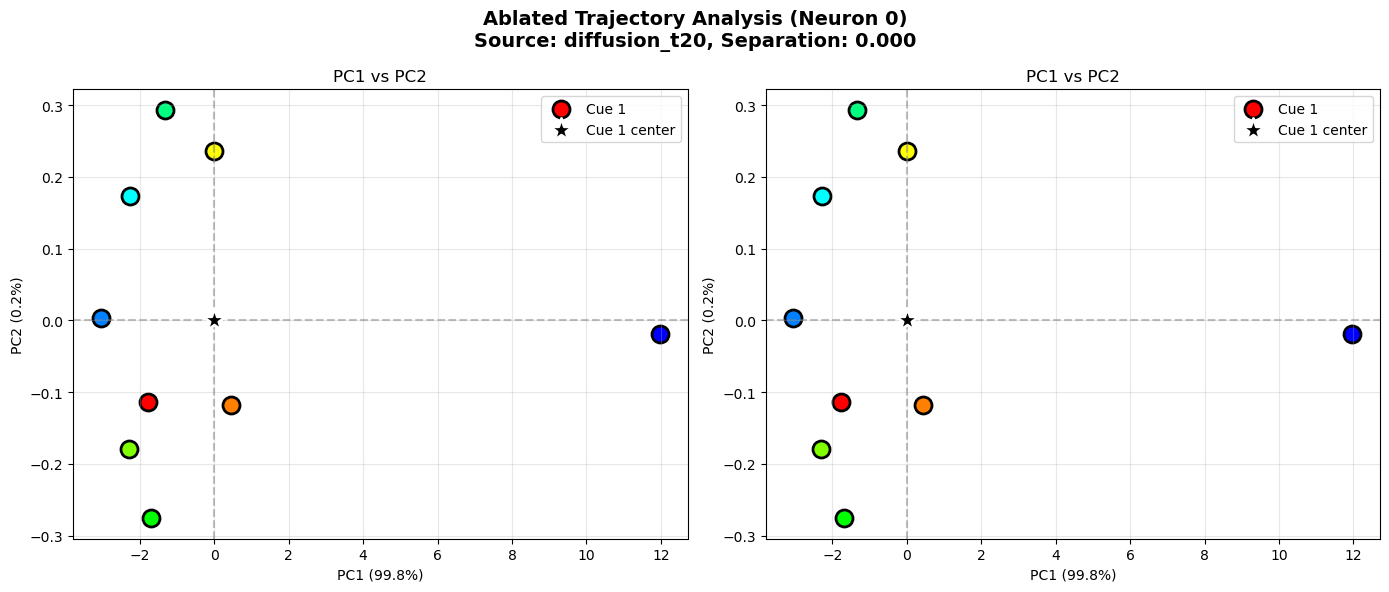


✓ Visualization complete


In [41]:
import colorsys

def angle_to_color(angle_deg):
    """Convert angle in degrees to RGB color."""
    hue = angle_deg / 360.0
    rgb = colorsys.hsv_to_rgb(hue, 1.0, 1.0)
    return rgb

# Check if PCA was performed
if pca is None or len(pca_coords) == 0:
    print("⚠ Skipping visualization - PCA was not performed due to insufficient data")
    print("Please fix the data issues identified in the previous cell and re-run.")
    fig = None
else:
    # Create mapping from original bin index to valid PCA row
    cue1_bin_to_pca_idx = {}
    cue2_bin_to_pca_idx = {}

    cue1_pca_idx = 0
    cue2_pca_idx = 0

    for bin_idx in range(N_BINS):
        # Check if this bin's cue 1 data is valid
        if valid_mask[bin_idx]:  # First N_BINS rows are cue 1
            cue1_bin_to_pca_idx[bin_idx] = cue1_pca_idx
            cue1_pca_idx += 1
        
        # Check if this bin's cue 2 data is valid
        if valid_mask[N_BINS + bin_idx]:  # Next N_BINS rows are cue 2
            cue2_bin_to_pca_idx[bin_idx] = cue2_pca_idx
            cue2_pca_idx += 1

    print(f"Valid bins - Cue 1: {len(cue1_bin_to_pca_idx)}, Cue 2: {len(cue2_bin_to_pca_idx)}")

    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot PC1 vs PC2
    for ax_idx, (pc_x, pc_y) in enumerate([(0, 1), (0, 2) if n_components > 2 else (0, 1)]):
        ax = axes[ax_idx]
        
        # Plot each bin colored by its angle
        for bin_idx in range(N_BINS):
            angle = bin_idx * (360 / N_BINS)
            color = angle_to_color(angle)
            
            # Cue 1 - only plot if this bin has valid data
            if bin_idx in cue1_bin_to_pca_idx:
                pca_idx = cue1_bin_to_pca_idx[bin_idx]
                ax.scatter(cue1_pca[pca_idx, pc_x], cue1_pca[pca_idx, pc_y], 
                          c=[color], s=150, marker='o', edgecolors='black', linewidth=2,
                          label=f'Cue 1' if bin_idx == 0 else '')
            
            # Cue 2 - only plot if this bin has valid data
            if bin_idx in cue2_bin_to_pca_idx:
                pca_idx = cue2_bin_to_pca_idx[bin_idx]
                ax.scatter(cue2_pca[pca_idx, pc_x], cue2_pca[pca_idx, pc_y], 
                          c=[color], s=150, marker='s', edgecolors='black', linewidth=2,
                          label=f'Cue 2' if bin_idx == 0 else '')
        
        # Plot centroids
        if len(cue1_pca) > 0:
            ax.scatter(cue1_center[pc_x], cue1_center[pc_y], 
                      c='black', s=300, marker='*', edgecolors='white', linewidth=2,
                      label='Cue 1 center', zorder=10)
        if len(cue2_pca) > 0:
            ax.scatter(cue2_center[pc_x], cue2_center[pc_y], 
                      c='black', s=300, marker='P', edgecolors='white', linewidth=2,
                      label='Cue 2 center', zorder=10)
        
        ax.set_xlabel(f'PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]:.1%})')
        ax.set_ylabel(f'PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]:.1%})')
        ax.set_title(f'PC{pc_x+1} vs PC{pc_y+1}')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

    # Get metadata for title
    meta = data.get('metadata', {})
    ablate_neuron = meta.get('ablate_neuron', '?')

    plt.suptitle(f'Ablated Trajectory Analysis (Neuron {ablate_neuron})\n'
                 f'Source: {source_name}, Separation: {separation:.3f}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\n✓ Visualization complete")

## 8. Save Results

In [42]:
# Create results directory
results_dir = TRAJECTORY_DATA_PATH.parent / "analysis_results"
results_dir.mkdir(exist_ok=True)

# Only save if PCA was successfully performed
if pca is not None and len(pca_coords) > 0:
    # Save PCA results
    results = {
        'pca_coords': pca_coords,
        'pca_explained_variance': pca.explained_variance_ratio_,
        'cue1_pca': cue1_pca,
        'cue2_pca': cue2_pca,
        'cue1_center': cue1_center,
        'cue2_center': cue2_center,
        'separation': separation,
        'averaged_states': averaged_states,
        'metadata': metadata,
        'config': {
            'timepoint': TIMEPOINT if not USE_PREP_STATES else f'prep_{PREP_IDX}',
            'n_bins': N_BINS,
            'angle_step': ANGLE_STEP,
            'source': source_name,
        }
    }

    np.save(results_dir / f'pca_results_{source_name}.npy', results)
    
    if fig is not None:
        fig.savefig(results_dir / f'pca_visualization_{source_name}.png', dpi=300, bbox_inches='tight')

    print(f"\n=== Results Saved ===")
    print(f"Directory: {results_dir}")
    print(f"  - pca_results_{source_name}.npy")
    if fig is not None:
        print(f"  - pca_visualization_{source_name}.png")
else:
    print(f"\n⚠ Skipping save - No valid results to save")
    print(f"PCA was not performed due to insufficient data")
    print(f"Please address the data issues and re-run the analysis")


=== Results Saved ===
Directory: /scratch3/shaiq_home/repos/behaviour_ddpm/results_link_sampler/index_cued_first_diffusion_0.3_swap_7/ablation_trajectories_neuron_0/analysis_results
  - pca_results_diffusion_t20.npy
  - pca_visualization_diffusion_t20.png


## 9. Additional Analysis: Trajectory Evolution (Optional)

Analyze how representations change across multiple timepoints.


=== Trajectory Evolution Analysis ===


/tmp/ipykernel_1111493/831821365.py:26: RuntimeWarning: Mean of empty slice.
  sep_t = np.linalg.norm(cue1_t.mean(axis=0) - cue2_t.mean(axis=0))
/scratch3/shaiq_home/anaconda3/envs/ddpm/lib/python3.11/site-packages/numpy/_core/_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/tmp/ipykernel_1111493/831821365.py:26: RuntimeWarning: Mean of empty slice.
  sep_t = np.linalg.norm(cue1_t.mean(axis=0) - cue2_t.mean(axis=0))
/scratch3/shaiq_home/anaconda3/envs/ddpm/lib/python3.11/site-packages/numpy/_core/_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/tmp/ipykernel_1111493/831821365.py:26: RuntimeWarning: Mean of empty slice.
  sep_t = np.linalg.norm(cue1_t.mean(axis=0) - cue2_t.mean(axis=0))
/scratch3/shaiq_home/anaconda3/envs/ddpm/lib/python3.11/site-packages/numpy/_core/_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/tmp/ipykernel_1111493/831821365.py:26: 

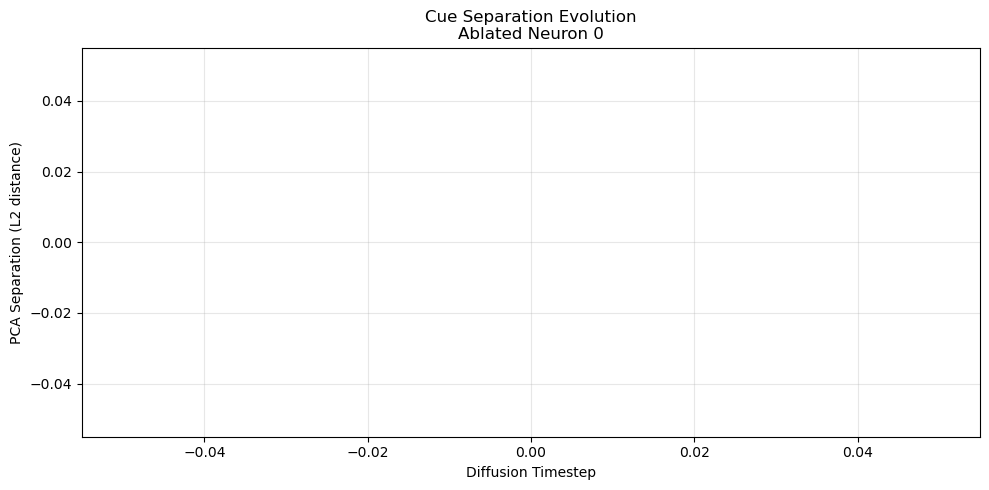


Separation over time:
  t= 0: nan
  t=10: nan
  t=20: nan
  t=30: nan
  t=39: nan

✓ Saved: separation_evolution.png


In [43]:
# Optional: Analyze multiple timepoints
if not USE_PREP_STATES and trajectories is not None:
    print("\n=== Trajectory Evolution Analysis ===")
    
    # Select timepoints to analyze
    timepoints_to_analyze = [0, 10, 20, 30, 39]  # Start, mid, end
    
    separations_over_time = []
    
    for t in timepoints_to_analyze:
        # Extract states at this timepoint
        states_t = trajectories[:, :, t, :].mean(dim=1).numpy()
        
        # Bin and average
        avg_t, _ = bin_and_average_by_cued_color(states_t, metadata, N_BINS)
        
        # PCA
        all_binned_t = np.vstack([avg_t[1], avg_t[2]])
        valid_t = ~np.isnan(all_binned_t).any(axis=1)
        pca_t = PCA(n_components=2)
        coords_t = pca_t.fit_transform(all_binned_t[valid_t])
        
        # Compute separation
        cue1_t = coords_t[:N_BINS]
        cue2_t = coords_t[N_BINS:2*N_BINS]
        sep_t = np.linalg.norm(cue1_t.mean(axis=0) - cue2_t.mean(axis=0))
        separations_over_time.append(sep_t)
    
    # Plot separation over time
    plt.figure(figsize=(10, 5))
    plt.plot(timepoints_to_analyze, separations_over_time, 'o-', linewidth=2, markersize=8)
    plt.xlabel('Diffusion Timestep')
    plt.ylabel('PCA Separation (L2 distance)')
    
    # Get ablated neuron from data metadata (not the trial metadata array)
    meta = data.get('metadata', {})
    ablate_neuron = meta.get('ablate_neuron', '?')
    plt.title(f'Cue Separation Evolution\nAblated Neuron {ablate_neuron}')
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(results_dir / 'separation_evolution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nSeparation over time:")
    for t, sep in zip(timepoints_to_analyze, separations_over_time):
        print(f"  t={t:2d}: {sep:.4f}")
    
    print(f"\n✓ Saved: separation_evolution.png")

## Summary

This notebook analyzed the ablated teacher trajectories and computed:
- Neural state representations at specific timepoint
- Binning by cued color
- PCA visualization showing cue/color encoding
- Separation between cue representations

**Next steps:**
- Compare with intact model trajectories
- Analyze multiple neurons ablated
- Look at trajectory evolution over time